In [1]:
from google.colab import files
uploaded = files.upload()

Saving red bean.jpg to red bean.jpg


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

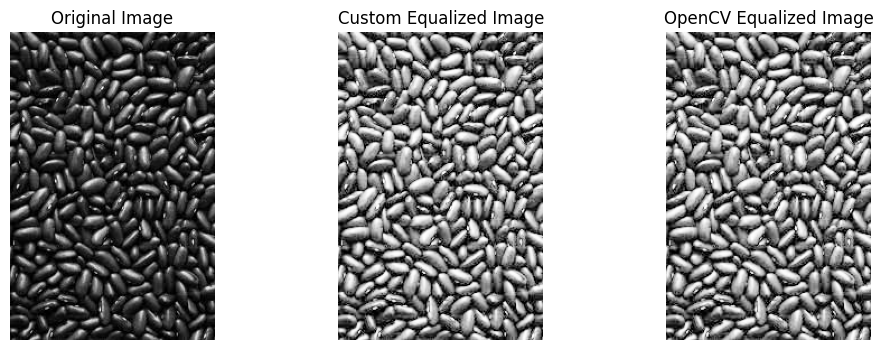

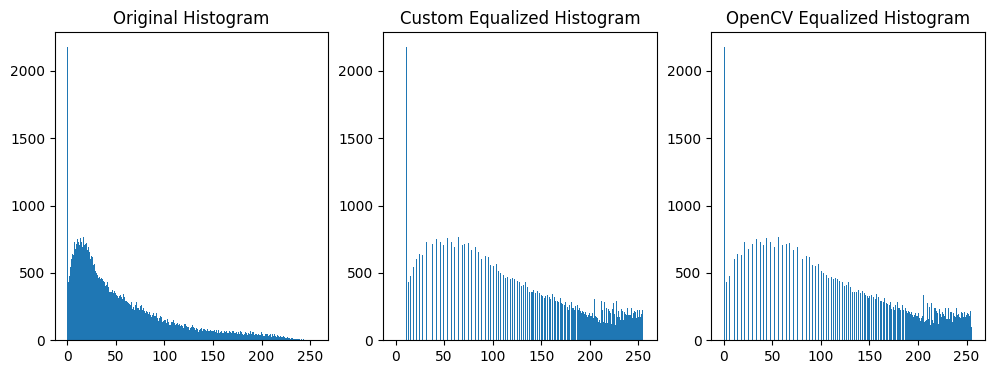

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def equalize_hist(image, L=256):
    intensity_levels, counts = np.unique(image, return_counts=True)
    total_pixels = image.size
    pdf = counts / total_pixels
    cdf = np.cumsum(pdf)
    transform = np.floor((L - 1) * cdf).astype(np.uint8)
    mapping = dict(zip(intensity_levels, transform))
    equalized_image = np.vectorize(mapping.get)(image)
    return equalized_image.astype(np.uint8)

image = cv2.imread("red bean.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Check the file path.")
else:
    custom_image = equalize_hist(image)
    opencv_image = cv2.equalizeHist(image)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(custom_image, cmap='gray')
    plt.title("Custom Equalized Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(opencv_image, cmap='gray')
    plt.title("OpenCV Equalized Image")
    plt.axis("off")

    plt.show()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.hist(image.ravel(), bins=256, range=[0, 256])
    plt.title("Original Histogram")

    plt.subplot(1, 3, 2)
    plt.hist(custom_image.ravel(), bins=256, range=[0, 256])
    plt.title("Custom Equalized Histogram")

    plt.subplot(1, 3, 3)
    plt.hist(opencv_image.ravel(), bins=256, range=[0, 256])
    plt.title("OpenCV Equalized Histogram")

    plt.show()